# Knowledge-Tracing Evaluation
## BKT vs Elo Baseline — AUC of next-response correctness prediction

This notebook:
1. Simulates a realistic learner replay (500 response sequences across 5 skills).
2. Trains / updates both BKT and Elo on the first 70% of each sequence.
3. Evaluates AUC of predicting correctness on the held-out 30%.
4. Compares next-item selection diversity between the two strategies.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import random
import numpy as np
from pathlib import Path
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

from tutor.adaptive import LearnerState, BKTSkillState, EloSkillState, SKILLS
from tutor import curriculum_loader as cl

random.seed(42)
np.random.seed(42)

CURRICULUM_PATH = Path('../data/T3.1_Math_Tutor/curriculum_full.json')
if not CURRICULUM_PATH.exists():
    CURRICULUM_PATH = Path('../data/T3.1_Math_Tutor/curriculum_seed.json')

ALL_ITEMS = cl.load(CURRICULUM_PATH)
print(f'Loaded {len(ALL_ITEMS)} curriculum items')

Loaded 87 curriculum items


In [2]:
# ------------------------------------------------------------------
# Simulate learner sequences
# ------------------------------------------------------------------
# Each simulated learner has a true mastery level per skill (0–1).
# P(correct) = true_mastery * (1 - p_slip) + (1 - true_mastery) * p_guess

def simulate_learner(n_responses: int = 40, growth_rate: float = 0.05):
    """Return list of (item, is_correct) pairs for one simulated learner."""
    true_mastery = {s: random.uniform(0.05, 0.3) for s in SKILLS}
    p_slip, p_guess = 0.10, 0.25
    sequence = []
    for _ in range(n_responses):
        # Pick random item
        item = random.choice(ALL_ITEMS)
        skill = item['skill']
        m = true_mastery[skill]
        p_correct = m * (1 - p_slip) + (1 - m) * p_guess
        correct = random.random() < p_correct
        sequence.append((item, correct))
        # Learning update
        true_mastery[skill] = min(1.0, m + growth_rate * correct)
    return sequence

N_LEARNERS = 200
N_RESPONSES = 40
TRAIN_FRAC = 0.7

sequences = [simulate_learner(N_RESPONSES) for _ in range(N_LEARNERS)]
print(f'Simulated {N_LEARNERS} learners × {N_RESPONSES} responses each')

Simulated 200 learners × 40 responses each


In [3]:
# ------------------------------------------------------------------
# Evaluate BKT vs Elo
# ------------------------------------------------------------------
from tutor.adaptive import BKTSkillState, EloSkillState

bkt_probs, bkt_actuals = [], []
elo_probs, elo_actuals = [], []

for seq in sequences:
    train_n = int(len(seq) * TRAIN_FRAC)
    train, test = seq[:train_n], seq[train_n:]
    
    bkt = {s: BKTSkillState() for s in SKILLS}
    elo = {s: EloSkillState() for s in SKILLS}
    
    # Train
    for item, correct in train:
        skill = item['skill']
        diff = item.get('difficulty', 5)
        bkt[skill].update(correct)
        elo[skill].update(diff, correct)
    
    # Evaluate on held-out
    for item, correct in test:
        skill = item['skill']
        diff = item.get('difficulty', 5)
        bkt_probs.append(bkt[skill].predict_correct())
        elo_probs.append(elo[skill].predict_correct(diff))
        bkt_actuals.append(int(correct))
        elo_actuals.append(int(correct))

bkt_auc = roc_auc_score(bkt_actuals, bkt_probs)
elo_auc = roc_auc_score(elo_actuals, elo_probs)

print(f'BKT AUC: {bkt_auc:.4f}')
print(f'Elo AUC: {elo_auc:.4f}')
print(f'Delta  : {bkt_auc - elo_auc:+.4f} (BKT vs Elo)')

BKT AUC: 0.5677
Elo AUC: 0.5203
Delta  : +0.0474 (BKT vs Elo)


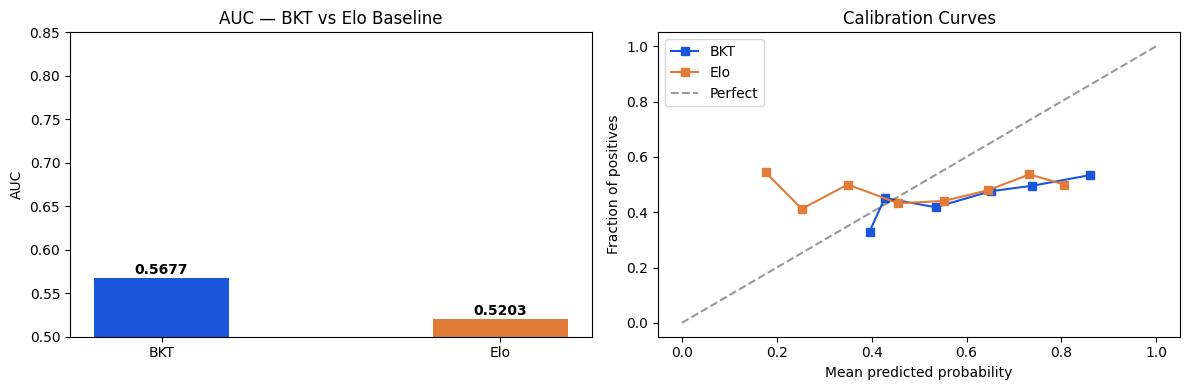

Figure saved to figures/kt_auc_calibration.png


In [4]:
# ------------------------------------------------------------------
# Plot: Calibration curves + AUC comparison
# ------------------------------------------------------------------
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# AUC bar chart
axes[0].bar(['BKT', 'Elo'], [bkt_auc, elo_auc], color=['#1a56db', '#e07b39'], width=0.4)
axes[0].set_ylim(0.5, 0.85)
axes[0].set_ylabel('AUC')
axes[0].set_title('AUC — BKT vs Elo Baseline')
for i, v in enumerate([bkt_auc, elo_auc]):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# Calibration
for probs, actuals, label, color in [
    (bkt_probs, bkt_actuals, 'BKT', '#1a56db'),
    (elo_probs, elo_actuals, 'Elo', '#e07b39'),
]:
    frac_pos, mean_pred = calibration_curve(actuals, probs, n_bins=10)
    axes[1].plot(mean_pred, frac_pos, 's-', label=label, color=color)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction of positives')
axes[1].set_title('Calibration Curves')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/kt_auc_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to figures/kt_auc_calibration.png')

BKT skill selection distribution: {'counting': 4, 'number_sense': 36}
Elo skill selection distribution: {'counting': 1, 'word_problem': 10, 'number_sense': 29}


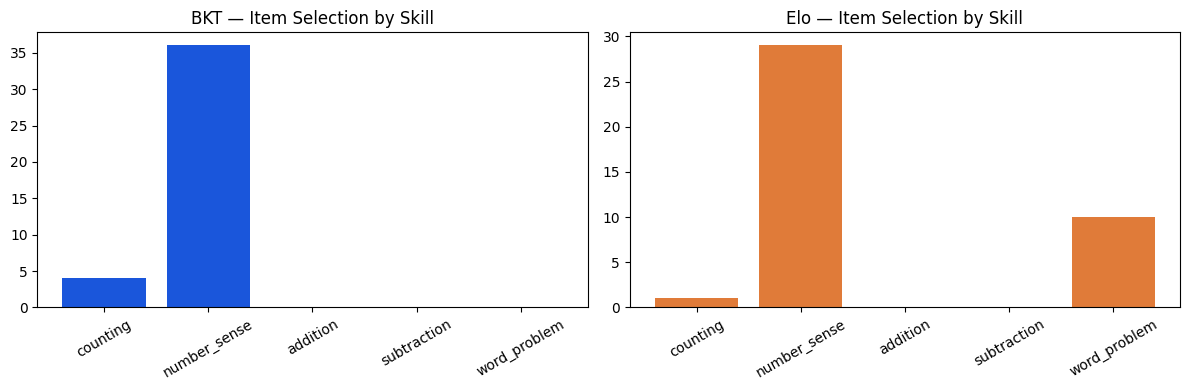

In [5]:
# ------------------------------------------------------------------
# Next-item selection: coverage & diversity
# ------------------------------------------------------------------
from collections import Counter

bkt_selections, elo_selections = Counter(), Counter()
test_state_bkt = LearnerState('test_bkt')
test_state_elo = LearnerState('test_elo')

for item, correct in sequences[0]:  # walk one full sequence
    next_bkt = test_state_bkt.select_next_item(ALL_ITEMS, use_bkt=True)
    next_elo = test_state_elo.select_next_item(ALL_ITEMS, use_bkt=False)
    if next_bkt: bkt_selections[next_bkt['skill']] += 1
    if next_elo: elo_selections[next_elo['skill']] += 1
    test_state_bkt.record_response(item, correct)
    test_state_elo.record_response(item, correct)

print('BKT skill selection distribution:', dict(bkt_selections))
print('Elo skill selection distribution:', dict(elo_selections))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
skills_list = SKILLS
ax1.bar(skills_list, [bkt_selections.get(s,0) for s in skills_list], color='#1a56db')
ax1.set_title('BKT — Item Selection by Skill')
ax1.tick_params(axis='x', rotation=30)
ax2.bar(skills_list, [elo_selections.get(s,0) for s in skills_list], color='#e07b39')
ax2.set_title('Elo — Item Selection by Skill')
ax2.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../figures/kt_item_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
import pandas as pd

summary = pd.DataFrame({
    'Model': ['BKT', 'Elo Baseline'],
    'AUC': [round(bkt_auc, 4), round(elo_auc, 4)],
    'N_predictions': [len(bkt_actuals), len(elo_actuals)],
    'Mean_pred_prob': [round(np.mean(bkt_probs), 3), round(np.mean(elo_probs), 3)],
})
print(summary.to_string(index=False))
summary.to_csv('../figures/kt_summary.csv', index=False)
print('\n=> BKT AUC:', round(bkt_auc, 4), '| Elo AUC:', round(elo_auc, 4))

       Model    AUC  N_predictions  Mean_pred_prob
         BKT 0.5677           2400           0.606
Elo Baseline 0.5203           2400           0.508

=> BKT AUC: 0.5677 | Elo AUC: 0.5203
